# Supervised Classification: Pilze

In diesem Notebook orientieren wir uns an der Struktur aus dem Unterrichtsnotebook `03_supervised_classification.ipynb`.

Ziel des Projektes ist es vorherzusagen, ob ein Pilz essbar e oder giftig p ist.

In [ ]:
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Daten laden

Der Datensatz ist mit ~ getrennt. Beim normalen Einlesen gab es ein paar Zeilen mit leeren Zusatzfeldern am Ende. Deshalb bereinigen wir diese Zeilen direkt beim Laden.

In [ ]:
project_path = Path.cwd()
if not (project_path / "data").exists():
    project_path = project_path.parent

data_path = project_path / "data/raw/mushroom_classification_data.csv"

cleaned_lines = []
fixed_lines = []

for line_number, line in enumerate(data_path.read_text(encoding="utf-8").splitlines(), start=1):
    parts = line.split("~")

    if len(parts) > 23 and all(value == "" for value in parts[23:]):
        fixed_lines.append(line_number)
        parts = parts[:23]

    cleaned_lines.append("~".join(parts))

data = read_csv(StringIO("\n".join(cleaned_lines)), sep="~")

print("Daten geladen:", data.shape)
print("Korrigierte Zeilen:", fixed_lines)
data.head()

Daten geladen: (8124, 23)
Korrigierte Zeilen: [6919, 7942, 8030]


,poison,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## EDA - Explorative Datenanalyse

Hier schauen wir uns den Datensatz kurz an und suchen nach möglichen Problemen.

In [ ]:
print(data.shape)
print(data["poison"].value_counts())

(8124, 23)
poison
e    4208
p    3916
Name: count, dtype: int64


In [ ]:
(data == "?").sum()[(data == "?").sum() > 0]

stalk-root    2480
dtype: int64

## Visualisierungen

Diese dienen als Hilfe den Datensatz besser zu verstehen.

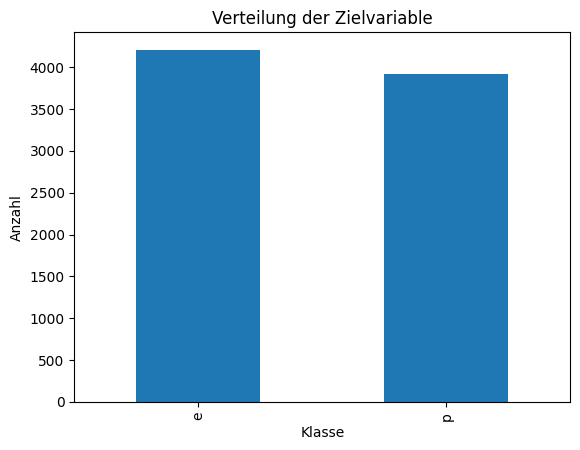

In [ ]:
data["poison"].value_counts().plot(kind="bar")
plt.title("Verteilung der Zielvariable")
plt.xlabel("Klasse")
plt.ylabel("Anzahl")
plt.show()

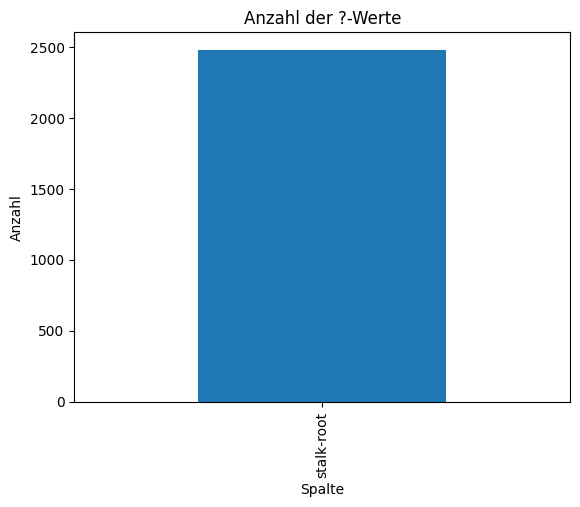

In [ ]:
missing_counts = (data == "?").sum()
missing_counts = missing_counts[missing_counts > 0]

missing_counts.plot(kind="bar")
plt.title("Anzahl der ?-Werte")
plt.xlabel("Spalte")
plt.ylabel("Anzahl")
plt.show()

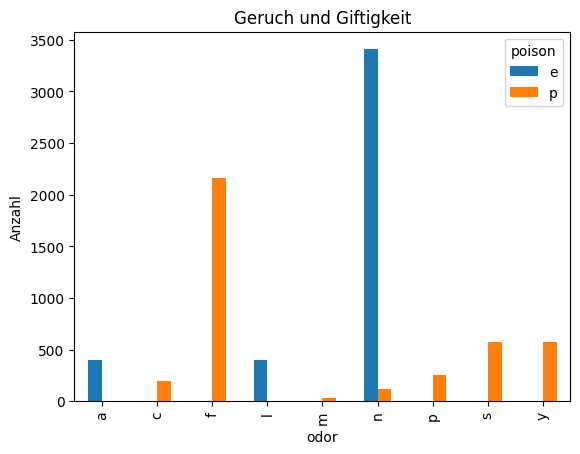

In [ ]:
pd.crosstab(data["odor"], data["poison"]).plot(kind="bar")
plt.title("Geruch und Giftigkeit")
plt.xlabel("odor")
plt.ylabel("Anzahl")
plt.show()

In [ ]:
data.nunique().sort_values()

veil-type                    1
poison                       2
bruises?                     2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
cap-surface                  4
ring-number                  4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
ring-type                    5
veil-color                   5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      8
stalk-color-above-ring       9
odor                         9
spore-print-color            9
stalk-color-below-ring      10
cap-color                   10
gill-color                  12
dtype: int64

Wir haben gesehen:

- Die Zielvariable ist relativ ausgeglichen.
- stalk-root enthält viele ?-Werte.
- veil-type hat nur einen einzigen Wert und bringt deshalb wahrscheinlich nichts für das Modell.
- Ein paar Werte wirken kaputt, zum Beispiel d**, 0.34, 0.3 und 0.4.

In [ ]:
data = data.replace(["d**", "0.34", "0.3", "0.4"], "?")
data.to_csv(project_path / "data/processed/mushroom_classification_clean.csv", index=False)

## Daten Vertical splitten (Input/Output)

Jetzt trennen wir die Eingabedaten X von der Zielvariable y.

In [ ]:
X = data.drop(columns=[
    "poison",
    "veil-type"
])

y = data[
    "poison"
]

## Daten horizontal Splitten (Train/Test)

Danach teilen wir die Daten in Trainingsdaten und Testdaten auf.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Daten Vorverarbeiten

Da unsere Daten nur kategoriale Spalten haben, brauchen wir keine Skalierung. Fehlende Werte ? werden vorher zu NaN, dann ersetzt und anschließend mit One-Hot-Encoding umgewandelt.

In [ ]:
X_train = X_train.replace("?", np.nan)
X_test = X_test.replace("?", np.nan)

cat_selector = make_column_selector(dtype_exclude=["number"])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, cat_selector)
])

Wir fitten die Vorverarbeitung nur auf den Trainingsdaten und wenden sie danach auf Trainings- und Testdaten an.

In [ ]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

## Model Entwicklung (Machine Learning)

Wie im Kursnotebook testen wir zuerst einen Entscheidungsbaum.

In [ ]:
tree_classifier = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

tree_classifier.fit(X_train_prep, y_train)

tree_prediction = tree_classifier.predict(X_test_prep)

print("F1", f1_score(y_test, tree_prediction, pos_label="p"))
print("Recall", recall_score(y_test, tree_prediction, pos_label="p"))
print("Precision", precision_score(y_test, tree_prediction, pos_label="p"))
print("Accuracy", accuracy_score(y_test, tree_prediction))

F1 0.9987212276214834
Recall 0.9974457215836526
Precision 1.0
Accuracy 0.9987692307692307


Zur Kontrolle schauen wir auch kurz auf die Trainingsdaten. Wenn Training viel besser wäre als Test, könnte das auf Overfitting hindeuten.

In [ ]:
tree_train_prediction = tree_classifier.predict(X_train_prep)

print("F1", f1_score(y_train, tree_train_prediction, pos_label="p"))
print("Recall", recall_score(y_train, tree_train_prediction, pos_label="p"))
print("Precision", precision_score(y_train, tree_train_prediction, pos_label="p"))
print("Accuracy", accuracy_score(y_train, tree_train_prediction))

F1 0.9996807151979565
Recall 0.999361634216406
Precision 1.0
Accuracy 0.9996922603477458


Zusätzlich testen wir noch KNN, weil das auch im Unterrichtsnotebook vorkommt.

In [ ]:
knn_classifier = KNeighborsClassifier(
    n_neighbors=9
)

knn_classifier.fit(X_train_prep, y_train)

knn_prediction = knn_classifier.predict(X_test_prep)

print("F1", f1_score(y_test, knn_prediction, pos_label="p"))
print("Recall", recall_score(y_test, knn_prediction, pos_label="p"))
print("Precision", precision_score(y_test, knn_prediction, pos_label="p"))
print("Accuracy", accuracy_score(y_test, knn_prediction))

F1 1.0
Recall 1.0
Precision 1.0
Accuracy 1.0


## Fazit

Beide Modelle funktionieren auf diesem Datensatz sehr gut.

Wichtig ist bei diesem Thema vor allem der Recall für giftige Pilze. Ein giftiger Pilz, der als essbar vorhergesagt wird, wäre der gefährlichste Fehler.